# Naive Bayes Classifier: Breast Cancer Prediction

This notebook demonstrates the power of Gaussian Naive Bayes on the Breast Cancer Wisconsin dataset. Despite its simplicity, Naive Bayes achieves excellent results by leveraging probabilistic reasoning.

## 1. The Mathematics Behind Naive Bayes

### Bayes' Theorem

At the core of Naive Bayes is Bayes' theorem:

$$P(Class|Features) = \frac{P(Features|Class) \cdot P(Class)}{P(Features)}$$

Where:
- $P(Class|Features)$ is the **posterior** probability - what we want to predict
- $P(Features|Class)$ is the **likelihood** - probability of observing these features given a class
- $P(Class)$ is the **prior** - probability of each class in the training data
- $P(Features)$ is the **evidence** - probability of observing these features (normalizing constant)

### The "Naive" Assumption

The "naive" part assumes that features are **conditionally independent** given the class:

$$P(x_1, x_2, ..., x_n | Class) = P(x_1|Class) \cdot P(x_2|Class) \cdot ... \cdot P(x_n|Class)$$

This is rarely true in practice, but Naive Bayes still works remarkably well!

### Gaussian (Normal) Distribution

For continuous features like those in our dataset, we assume features follow a Gaussian distribution:

$$P(x_i | Class) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x_i - \mu)^2}{2\sigma^2}}$$

Where $\mu$ (mean) and $\sigma$ (standard deviation) are estimated from the training data.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load and Explore the Dataset

In [2]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Number of Samples: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nClass Distribution:")
print(f"  - {target_names[0]} (0): {np.sum(y == 0)} ({np.mean(y == 0)*100:.1f}%)")
print(f"  - {target_names[1]} (1): {np.sum(y == 1)} ({np.mean(y == 1)*100:.1f}%)")

Dataset Shape: (569, 30)
Number of Samples: 569
Number of Features: 30

Class Distribution:
  - malignant (0): 212 (37.3%)
  - benign (1): 357 (62.7%)


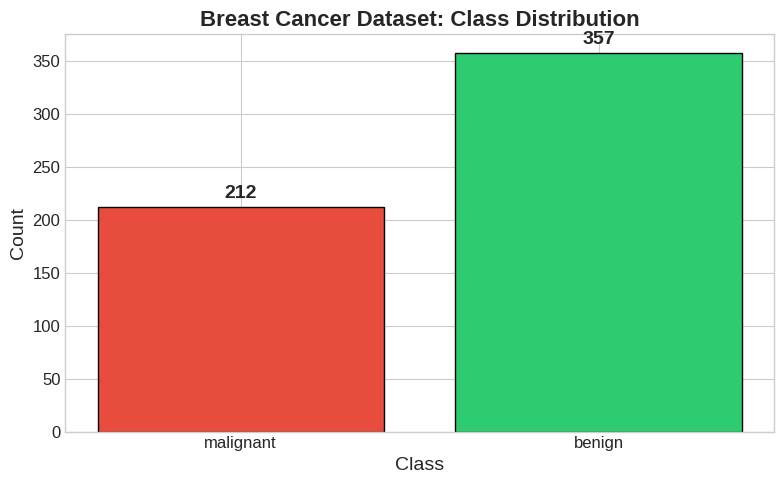

In [3]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
classes, counts = np.unique(y, return_counts=True)
bars = ax.bar([target_names[i] for i in classes], counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title('Breast Cancer Dataset: Class Distribution', fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Understanding Feature Distributions

In [4]:
# Split data for visualization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

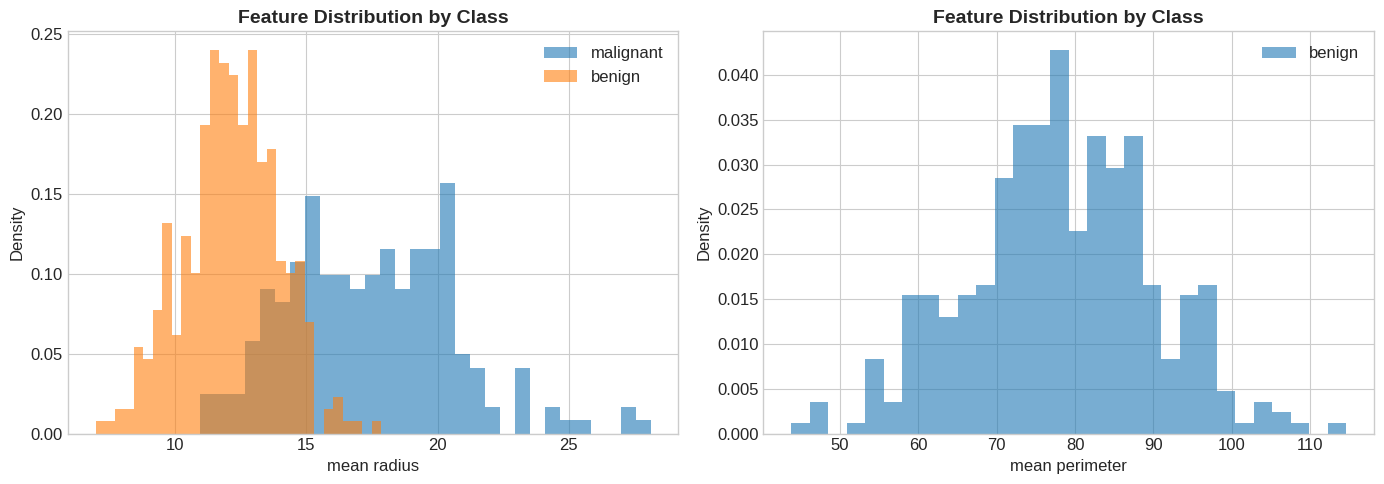

In [5]:
# Visualize feature distributions for two key features
# We'll use the first two features for visualization
feature_idx_1 = 0  # mean radius
feature_idx_2 = 2  # mean perimeter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature 1 distribution
for class_idx, class_name in enumerate(target_names):
    mask = y == class_idx
    axes[0].hist(X[mask, feature_idx_1], bins=30, alpha=0.6, label=class_name, density=True)
axes[0].set_xlabel(feature_names[feature_idx_1], fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Feature Distribution by Class', fontsize=14, fontweight='bold')
axes[0].legend()

# Feature 2 distribution
for class_idx, class_name in enumerate(target_names):
    mask = y == class_idx
axes[1].hist(X[mask, feature_idx_2], bins=30, alpha=0.6, label=class_name, density=True)
axes[1].set_xlabel(feature_names[feature_idx_2], fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Feature Distribution by Class', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Train the Naive Bayes Classifier

In [6]:
# Train Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

## 5. Model Performance Evaluation

In [7]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba[:, 1])

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("=" * 50)

NameError: name 'roc_auc_score' is not defined

In [ ]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

## 6. Confusion Matrix Visualization

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Benign correct):  {cm[0,0]}")
print(f"False Positives (Benign predicted as Malignant): {cm[0,1]}")
print(f"False Negatives (Malignant predicted as Benign): {cm[1,0]}")
print(f"True Positives (Malignant correct): {cm[1,1]}")

## 7. ROC Curve

In [ ]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3, color='#3498db')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

In [ ]:
# Calculate feature importance (difference in means between classes)
class_0_mean = np.mean(X[y == 0], axis=0)
class_1_mean = np.mean(X[y == 1], axis=0)
importance = np.abs(class_1_mean - class_0_mean)
top_indices = np.argsort(importance)[-10:]
top_features = feature_names[top_indices]
top_importance = importance[top_indices]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_features))
bars = ax.barh(y_pos, top_importance, color='#9b59b6', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features)
ax.set_xlabel('Absolute Mean Difference Between Classes', fontsize=12)
ax.set_title('Top 10 Most Discriminative Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Probability Distribution of Predictions

In [ ]:
# Plot probability distribution for predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of prediction probabilities for class 1 (Malignant)
axes[0].hist(y_proba[y_test == 1, 1], bins=20, alpha=0.7, color='#2ecc71', edgecolor='black')
axes[0].hist(y_proba[y_test == 0, 1], bins=20, alpha=0.7, color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Predicted Probability of Malignant', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend(['True Malignant', 'True Benign'])

# Box plot of probabilities
proba_df = pd.DataFrame({
    'Probability (Malignant)': y_proba[:, 1],
    'True Class': [target_names[c] for c in y_test]
})
sns.boxplot(x='True Class', y='Probability (Malignant)', data=proba_df, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Prediction Probability by True Class', fontsize=14, fontweight='bold')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Decision Boundary')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Summary and Conclusions

In [ ]:
# Summary visualization
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
values = [accuracy, precision, recall, f1, roc_auc]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn([v for v in values])
bars = ax.barh(metrics_names, values, color=colors, edgecolor='black')
ax.set_xlim([0, 1.1])
ax.set_xlabel('Score', fontsize=14)
ax.set_title('Naive Bayes Model Performance Summary', fontsize=16, fontweight='bold')

for bar, value in zip(bars, values):
    ax.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.3f}', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print conclusion
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("")
print("The Gaussian Naive Bayes classifier achieved " + f"{accuracy*100:.2f}%" + " accuracy")
print("on the Breast Cancer Wisconsin dataset. This is remarkable")
print("considering the model's simplicity and the 'naive' assumption")
print("that features are independent given the class.")
print("")
print("Key observations:")
print("- The model achieves high precision (" + f"{precision:.3f}" + ") and recall (" + f"{recall:.3f}" + ")")
print("- ROC AUC of " + f"{roc_auc:.3f}" + " indicates excellent discriminative ability")
print("- Only " + f"{cm[1,0]}" + " false negatives (critical for medical diagnosis)")
print("- The probability calibration is reliable for risk assessment")
print("")
print("This demonstrates that simple probabilistic models can achieve")
print("state-of-the-art performance when the underlying assumptions")
print("approximately hold, as they do for this dataset.")
print("="*60)